In [99]:
import pandas as pd
import matplotlib.pyplot as plt

In [100]:
data = pd.read_csv("../../data/US-pumpkins.csv")
data = data[data['Package'].str.contains('bushel', case=True, regex=True)]
print(data.head())

    City Name Type               Package   Variety Sub Variety  Grade  \
70  BALTIMORE  NaN  1 1/9 bushel cartons  PIE TYPE         NaN    NaN   
71  BALTIMORE  NaN  1 1/9 bushel cartons  PIE TYPE         NaN    NaN   
72  BALTIMORE  NaN  1 1/9 bushel cartons  PIE TYPE         NaN    NaN   
73  BALTIMORE  NaN  1 1/9 bushel cartons  PIE TYPE         NaN    NaN   
74  BALTIMORE  NaN  1 1/9 bushel cartons  PIE TYPE         NaN    NaN   

       Date  Low Price  High Price  Mostly Low  ...  Unit of Sale Quality  \
70  9/24/16       15.0        15.0        15.0  ...           NaN     NaN   
71  9/24/16       18.0        18.0        18.0  ...           NaN     NaN   
72  10/1/16       18.0        18.0        18.0  ...           NaN     NaN   
73  10/1/16       17.0        17.0        17.0  ...           NaN     NaN   
74  10/8/16       15.0        15.0        15.0  ...           NaN     NaN   

   Condition Appearance Storage  Crop Repack  Trans Mode  Unnamed: 24  \
70       NaN        NaN  

In [101]:
data.info()


<class 'pandas.DataFrame'>
Index: 415 entries, 70 to 1742
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   City Name        415 non-null    str    
 1   Type             9 non-null      str    
 2   Package          415 non-null    str    
 3   Variety          415 non-null    str    
 4   Sub Variety      248 non-null    str    
 5   Grade            0 non-null      float64
 6   Date             415 non-null    str    
 7   Low Price        415 non-null    float64
 8   High Price       415 non-null    float64
 9   Mostly Low       391 non-null    float64
 10  Mostly High      391 non-null    float64
 11  Origin           415 non-null    str    
 12  Origin District  19 non-null     str    
 13  Item Size        301 non-null    str    
 14  Color            270 non-null    str    
 15  Environment      0 non-null      float64
 16  Unit of Sale     11 non-null     str    
 17  Quality          0 non-null   

In [102]:
data.isnull().sum()


City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

In [103]:
columns_to_select = ["Package", "Low Price", "High Price", "Date", "Variety", "City Name"]
data = data.loc[:, columns_to_select]
data['City'] = data['City Name']
print(data.head())


                 Package  Low Price  High Price     Date   Variety  City Name  \
70  1 1/9 bushel cartons       15.0        15.0  9/24/16  PIE TYPE  BALTIMORE   
71  1 1/9 bushel cartons       18.0        18.0  9/24/16  PIE TYPE  BALTIMORE   
72  1 1/9 bushel cartons       18.0        18.0  10/1/16  PIE TYPE  BALTIMORE   
73  1 1/9 bushel cartons       17.0        17.0  10/1/16  PIE TYPE  BALTIMORE   
74  1 1/9 bushel cartons       15.0        15.0  10/8/16  PIE TYPE  BALTIMORE   

         City  
70  BALTIMORE  
71  BALTIMORE  
72  BALTIMORE  
73  BALTIMORE  
74  BALTIMORE  


In [104]:
data['Avg Price'] = (data['Low Price'] + data['High Price']) / 2
data["Month"] = pd.DatetimeIndex(data['Date']).month

print(data.head())


                 Package  Low Price  High Price     Date   Variety  City Name  \
70  1 1/9 bushel cartons       15.0        15.0  9/24/16  PIE TYPE  BALTIMORE   
71  1 1/9 bushel cartons       18.0        18.0  9/24/16  PIE TYPE  BALTIMORE   
72  1 1/9 bushel cartons       18.0        18.0  10/1/16  PIE TYPE  BALTIMORE   
73  1 1/9 bushel cartons       17.0        17.0  10/1/16  PIE TYPE  BALTIMORE   
74  1 1/9 bushel cartons       15.0        15.0  10/8/16  PIE TYPE  BALTIMORE   

         City  Avg Price  Month  
70  BALTIMORE       15.0      9  
71  BALTIMORE       18.0      9  
72  BALTIMORE       18.0     10  
73  BALTIMORE       17.0     10  
74  BALTIMORE       15.0     10  


In [105]:
new_data = data[data['Package'].str.contains('bushel')]

mask_1_19 = new_data['Package'].str.contains('1 1/9')
mask_12 = new_data['Package'].str.contains('1/2')

new_data.loc[mask_1_19, 'Avg Price'] = new_data.loc[mask_1_19, 'Avg Price'] / (1 + 1/9)
new_data.loc[mask_12, 'Avg Price'] = new_data.loc[mask_12, 'Avg Price'] / (1/2)


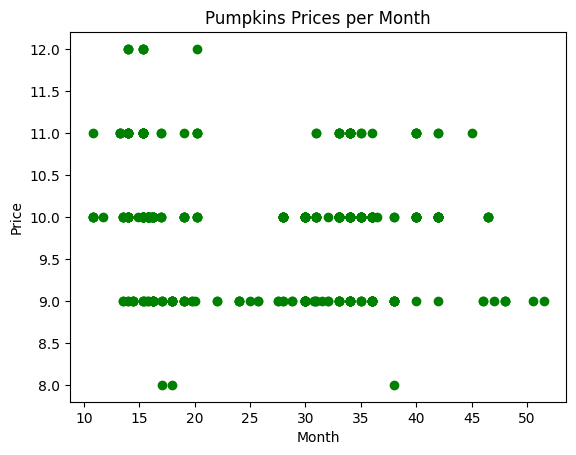

In [106]:

plt.title("Pumpkins Prices per Month")
plt.scatter(new_data["Avg Price"], new_data["Month"], color="green")
plt.xlabel("Month")
plt.ylabel("Price")
plt.show()


Text(0, 0.5, 'Pumpkin Price')

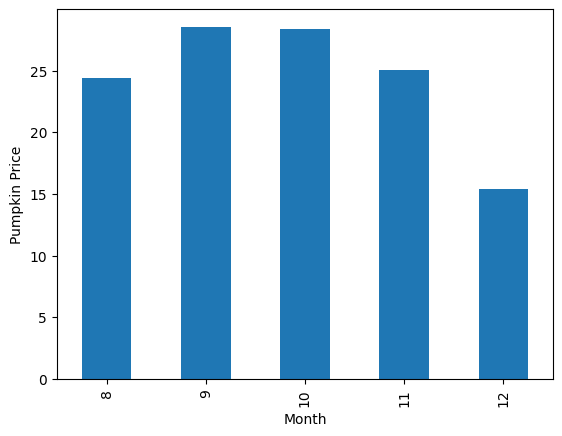

In [107]:
new_data.groupby(['Month'])['Avg Price'].mean().plot(kind='bar')
plt.ylabel("Pumpkin Price")

In [108]:
from datetime import datetime

new_data['DayOfYear'] = pd.to_datetime(new_data['Date']).apply(lambda dt: (dt - datetime(dt.year, 1, 1)).days)
print(new_data['DayOfYear'])

70      267
71      267
72      274
73      274
74      281
       ... 
1738    273
1739    273
1740    273
1741    273
1742    273
Name: DayOfYear, Length: 415, dtype: int64


/var/folders/c8/w5653zh95fv3vzdrz0pxdvc80000gn/T/ipykernel_32813/3243404418.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_data['DayOfYear'] = pd.to_datetime(new_data['Date']).apply(lambda dt: (dt - datetime(dt.year, 1, 1)).days)


In [109]:
print(new_data['Month'].corr(new_data['Avg Price']))
print(new_data['DayOfYear'].corr(new_data['Avg Price']))

-0.14912913634278605
-0.16690092505934478


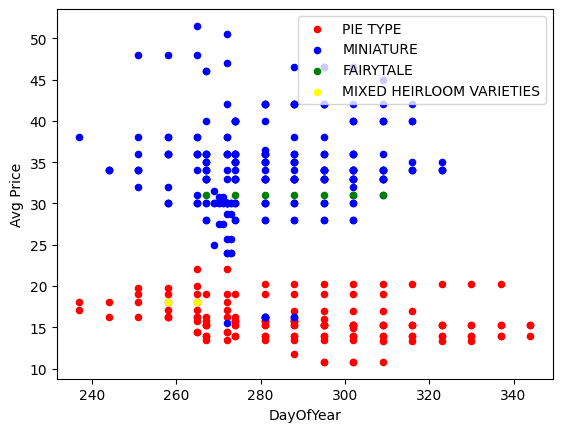

In [110]:
ax = None
colors= ['red', 'blue', 'green', 'yellow']
for i,var in enumerate(new_data['Variety'].unique()):
    df = new_data[new_data['Variety'] == var]
    ax = df.plot.scatter('DayOfYear', 'Avg Price', ax=ax, c=colors[i], label=var)

<Axes: xlabel='Variety'>

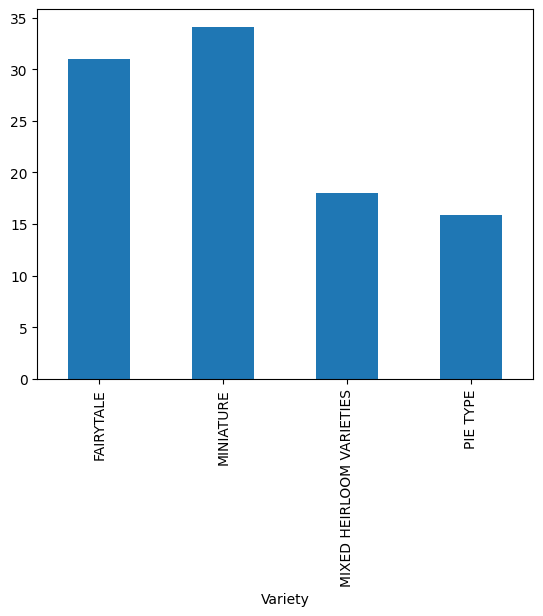

In [111]:
new_data.groupby('Variety')['Avg Price'].mean().plot(kind='bar')

In [112]:
pd.get_dummies(new_data['Variety'])

,FAIRYTALE,MINIATURE,MIXED HEIRLOOM VARIETIES,PIE TYPE
70,False,False,False,True
71,False,False,False,True
72,False,False,False,True
73,False,False,False,True
74,False,False,False,True
...,...,...,...,...
1738,False,True,False,False
1739,False,True,False,False
1740,False,True,False,False
1741,False,True,False,False


In [113]:
x = pd.get_dummies(new_data['Variety'])
y = new_data['Avg Price']

In [114]:
x = pd.get_dummies(new_data['Variety']).join(new_data['Month']).join(pd.get_dummies(new_data['City'])).join(pd.get_dummies(new_data['Package']))
y = new_data['Avg Price']

In [115]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

In [117]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
pipeline.fit(x_train, y_train)

pred = pipeline.predict(x_test)
rmse = mean_squared_error(y_test, pred)
print(f"RMSE: {rmse:3.3} ({rmse/pred.mean()*100:3.3}%)")

score = pipeline.score(x_train, y_train)
print(f"Model determination: {score}")

RMSE: 4.97 (18.5%)
Model determination: 0.9658747228525119
